In [1]:
from tara_preprocessing import full_preprocessing,make_rbf_correlation_matrix,get_just_ecog_data,get_electrode_normalized_loc
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_root = Path("/Users/noahwanless/Desktop/Spring2026/M467/faces_basic/data")
registered_dir = Path("../SuperEeg-M467-project/registered_outputs")
ecogs = get_just_ecog_data(registered_dir,data_root)
xyz = get_electrode_normalized_loc(registered_dir)

[PosixPath('../SuperEeg-M467-project/registered_outputs/aa_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ap_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ca_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/de_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/fp_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ha_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ja_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jm_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jt_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/mv_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/rn_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_output

In [3]:
xyz_clean, mapping_clean, kept_global_indices, cleaned = full_preprocessing(ecogs,xyz)

(649, 3)
(649, 2)


In [4]:
import scipy
print(scipy.__version__)

1.15.3


In [1]:
correlation_matrices = make_rbf_correlation_matrix(xyz_clean,cleaned,mapping_clean)

NameError: name 'make_rbf_correlation_matrix' is not defined

In [22]:
correlation_matrix = np.load("/Users/noahwanless/Desktop/Spring2026/M467/gitproject/SuperEeg-M467-project/correlation_matrix.npy")
correlation_matrix.shape

(509, 509)

We are trying in this example to predict for one patient

we pretend they only have 9 known electrodes that they observed (electrodes 0-9) for patient 0, while the next 30 or so we do actually know but we predent not to for the sake of comparasion, the names of the vars are similar to the eqaution from the paper

# This is trying to predict for patient 1

In [52]:
def single_patient_prediction(patient,electrodestart,electrodeend,ecogs,correlation_matrix):
    #this gets everything for this patient, the correlation of the observed and unobserved datapoints
    Y = ecogs[patient] #gets this paitents data
    row_means = np.mean(Y, axis=0, keepdims=True)
    row_stds = np.std(Y, axis=0, keepdims=True)
    Y_z_score = (Y - row_means) / row_stds #turns them into there z_score for each value in the data
    print('Y_z_score.shape')
    print(Y_z_score.shape)
    K_patient = correlation_matrix[:,electrodestart:electrodeend+1] #this gets all the electrodes that the patient has with their own correlation and that of others
    print('K_patient.shape')
    print(K_patient.shape)
    Kalpha_alpha = K_patient[electrodestart:electrodeend+1,:] #gets all the rows that the patient has observed data for
    print('Kalpha_alpha.shape')
    print(Kalpha_alpha.shape)
    Kbeta_alpha = K_patient[electrodeend+1:,:] #get all rows the patient doestn have observed 
    print('Kbeta_alpha.shape')
    print(Kbeta_alpha.shape)
    Y_patient = Y_z_score[:,electrodestart:electrodeend+1] #gets all the z_score values from electrodes the patient we did observed
    print('Y_patient.shape')
    print(Y_patient.shape)
    Y_true = Y_z_score[:,electrodeend+1:] #gets all the z_score values from electrodes the patient we didnt observed (for potential comparison later)
    print('Y_true.shape')
    print(Y_true.shape)
    Yt = Y_patient.T #take the transpose of it
    Kalpha_alpha_inv = np.linalg.inv(Kalpha_alpha) 
    pred = ((Kbeta_alpha@Kalpha_alpha_inv)@Yt).T #using formula from paper
    print('pred.shape')
    print(pred.shape)
    return pred, Y_true #! NOTE: keep the 'Y_true' in the return if you want to use for comparision purposes with know things of the patient

    

In [53]:
pred,y_real = single_patient_prediction(0,0,10,ecogs,correlation_matrix)


Y_z_score.shape
(271400, 46)
K_patient.shape
(509, 11)
Kalpha_alpha.shape
(11, 11)
Kbeta_alpha.shape
(498, 11)
Y_patient.shape
(271400, 11)
Y_true.shape
(271400, 35)
pred.shape
(271400, 498)


In [21]:
print(pred.shape)
print(y_real.shape)

(271400, 498)
(271400, 36)


(271400, 36)


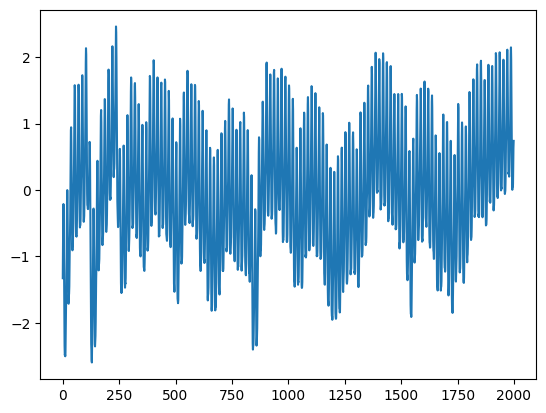

In [8]:
plt.plot(y_real[2000:4000,0])
print(y_real.shape)

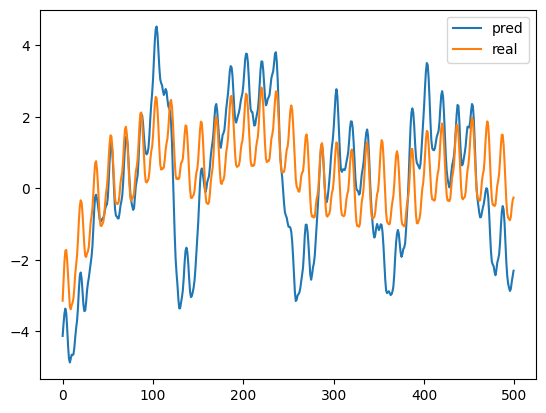

In [51]:
plt.plot(pred[2000:2500,0],label='pred')
plt.plot(y_real[2000:2500,0],label='real')
#plt.plot(ecogs[0][2000:3000,0+9],label='real')
plt.legend()

In [46]:

Y = ecogs[0] #this is the data we have of this patient
row_means = np.mean(Y, axis=0, keepdims=True)
row_stds = np.std(Y, axis=0, keepdims=True)
row_means.shape
Y_z_score = (Y - row_means) / row_stds

In [47]:
Y_z_score

array([[1.20007840e-03, 1.69490169e-03, 9.18826813e-05, ...,
        8.63667313e-04, 2.22882553e-03, 3.28483104e-03],
       [1.20076941e-03, 1.70068519e-03, 9.41755131e-05, ...,
        8.73822247e-04, 2.23571791e-03, 3.28506552e-03],
       [1.20651575e-03, 1.71638737e-03, 1.04572234e-04, ...,
        8.96723875e-04, 2.25223018e-03, 3.28941142e-03],
       ...,
       [1.20907528e-03, 1.71358956e-03, 1.04904808e-04, ...,
        8.74485293e-04, 2.23710757e-03, 3.29240623e-03],
       [1.20272541e-03, 1.69888962e-03, 9.53485378e-05, ...,
        8.64632711e-04, 2.22972678e-03, 3.28726217e-03],
       [1.20105518e-03, 1.69458701e-03, 9.29105168e-05, ...,
        8.61818291e-04, 2.22782720e-03, 3.28583250e-03]],
      shape=(271400, 46))

In [49]:
electrodestart = 0
electrodeend = 10
print(correlation_matrix.shape)
K_patient = correlation_matrix[:,electrodestart:electrodeend+1] #this gets all the electrodes that the patient has with their own data and the data of others
Kalpha_alpha = K_patient[electrodestart:electrodeend+1,:] #gets all the rows that the patient has observed data for
Kbeta_alpha = K_patient[electrodeend+1:,:]

Y_patient = Y_z_score[:,electrodestart:electrodeend+1]
Yt = Y_patient.T #take the transpose of it
print(Yt.shape)

(509, 509)
(11, 271400)


In [18]:
Kbeta_alpha.shape

(498, 11)

In [28]:
Yt.shape

(11, 271400)

In [19]:
Kalpha_alpha.shape

(11, 11)

In [50]:
Kalpha_alpha_inv = np.linalg.inv(Kalpha_alpha)

In [51]:
pred = (Kbeta_alpha@Kalpha_alpha_inv)@Yt

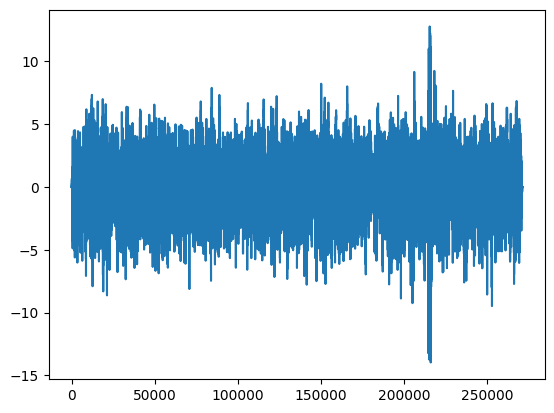

In [52]:
import matplotlib.pyplot as plt

plt.plot(pred[0])

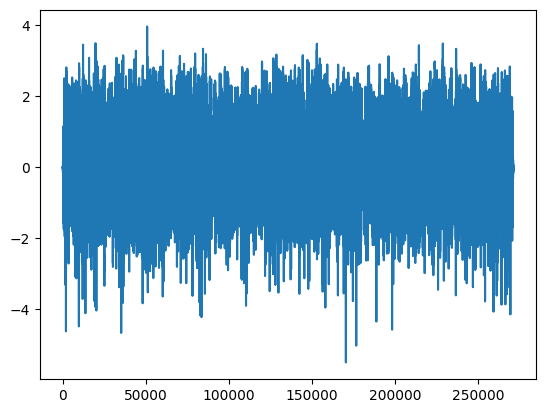

In [54]:
plt.plot(Y_z_score[:,11])
#plt.plot(ecogs[0])